# GHAW-H Dataset Overview

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pavt/GHAW-H/blob/main/notebooks/dataset_overview.ipynb)

Overview statistics and cumulative adoption figures for **A Dataset of GitHub Agentic Workflow Histories: Early Adopters**.

The notebook sets up its dependencies, loads the published Parquet tables, produces summary tables, and plots cumulative trends.


In [1]:
from __future__ import annotations

import importlib.util
import subprocess
import sys
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

if "google.colab" in sys.modules:
    missing = [
        package
        for package, import_name in REQUIRED_PACKAGES.items()
        if importlib.util.find_spec(import_name) is None
    ]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

DATASET_ID = "pavtch/GHAW-H"
DATASET_REVISION = "main"
LOCAL_RELEASE_CANDIDATES = [
    Path(".."),
    Path("."),
    Path("../releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("releases/gh-aw-early-adopters-source-history-2026-06-26"),
    Path("../releases/gawd"),
    Path("releases/gawd"),
]
LOCAL_RELEASE_MIRROR = next(
    (
        path.resolve()
        for path in LOCAL_RELEASE_CANDIDATES
        if (path / "data").is_dir() and any((path / "data").glob("*.parquet"))
    ),
    None,
)
USE_LOCAL_MIRROR = "google.colab" not in sys.modules and LOCAL_RELEASE_MIRROR is not None


def remote_parquet_url(table_name: str) -> str:
    return (
        f"https://huggingface.co/datasets/{DATASET_ID}/resolve/"
        f"{DATASET_REVISION}/data/{table_name}.parquet"
    )


def local_parquet_path(table_name: str) -> Path:
    if LOCAL_RELEASE_MIRROR is None:
        raise FileNotFoundError("No local release mirror with a data/ directory was found.")
    return LOCAL_RELEASE_MIRROR / "data" / f"{table_name}.parquet"


def parquet_path(table_name: str) -> str:
    if USE_LOCAL_MIRROR:
        return str(local_parquet_path(table_name))
    return remote_parquet_url(table_name)


def read_parquet_table(table_name: str) -> pd.DataFrame:
    if USE_LOCAL_MIRROR:
        return pd.read_parquet(local_parquet_path(table_name))

    try:
        with urlopen(remote_parquet_url(table_name)) as response:
            return pd.read_parquet(BytesIO(response.read()))
    except Exception:
        if LOCAL_RELEASE_MIRROR is not None:
            return pd.read_parquet(local_parquet_path(table_name))
        raise

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.0,
        "axes.labelsize": 14,
        "axes.titlesize": 15,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 11,
        "figure.dpi": 160,
    }
)
sns.set_style("whitegrid")

NOTEBOOK_DIR = Path("data_analysis") if Path("data_analysis").is_dir() else Path(".")
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig: plt.Figure, out: Path) -> None:
    png_out = out.with_suffix(".png")
    pdf_out = out.with_suffix(".pdf")
    fig.savefig(png_out, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_out, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_out)))
    print("Wrote", png_out)
    print("Wrote", pdf_out)


In [2]:
# ----------------------- Utils -----------------------
def load_tables() -> dict[str, pd.DataFrame]:
    return {
        "repository": read_parquet_table("repository"),
        "source_markdown_file_snapshot": read_parquet_table("source_markdown_file_snapshot"),
        "source_markdown_file_version": read_parquet_table("source_markdown_file_version"),
        "source_markdown_file_history": read_parquet_table("source_markdown_file_history"),
        "lock_file_snapshot": read_parquet_table("lock_file_snapshot"),
    }


def build_version_events(tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    events = (
        tables["source_markdown_file_version"].merge(
            tables["source_markdown_file_snapshot"],
            on="source_markdown_file_snapshot_id",
            how="inner",
            validate="many_to_one",
        )
        .merge(
            tables["repository"],
            on="repository_id",
            how="left",
            validate="many_to_one",
        )
    )
    events["committed_at"] = pd.to_datetime(events["committed_at"], utc=True, errors="coerce")
    events = events.dropna(subset=["committed_at"]).copy()
    events["committed_month"] = (
        events["committed_at"].dt.tz_convert(None).dt.to_period("M").dt.to_timestamp()
    )
    return events.sort_values(["repository_id", "committed_at", "rank"])


def build_adoption_table(version_events: pd.DataFrame) -> pd.DataFrame:
    adoption = (
        version_events.groupby("repository_id", as_index=False)
        .agg(
            repo_full_name=("repo_full_name", "first"),
            main_language=("main_language", "first"),
            license=("license", "first"),
            stars=("stars", "first"),
            forks=("forks", "first"),
            adoption_date=("committed_at", "first"),
            first_source_path=("path", "first"),
            observed_versions=("source_markdown_file_version_id", "count"),
            observed_source_paths=("path", "nunique"),
        )
        .sort_values("adoption_date")
        .reset_index(drop=True)
    )
    adoption["adoption_month"] = (
        adoption["adoption_date"].dt.tz_convert(None).dt.to_period("M").dt.to_timestamp()
    )
    return adoption


def monthly_cumulative(adoption_df: pd.DataFrame) -> pd.DataFrame:
    monthly = (
        adoption_df.groupby("adoption_month", as_index=False)
        .agg(new_repositories=("repository_id", "count"))
        .sort_values("adoption_month")
    )
    monthly["cumulative_repositories"] = monthly["new_repositories"].cumsum()
    monthly["month_label"] = monthly["adoption_month"].dt.strftime("%Y-%m")
    return monthly


def plot_cumulative(monthly: pd.DataFrame, title: str, fname_stub: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_df = monthly.copy()
    plot_df["month_index"] = range(len(plot_df))
    x = plot_df["month_index"]
    y = plot_df["cumulative_repositories"].astype(int)

    ax.fill_between(x, y, color="#4C78A8", alpha=0.58)
    ax.plot(x, y, color="black", linewidth=1.8, marker="o", markersize=5)
    for xpos, value in zip(x, y, strict=True):
        ax.annotate(
            f"{value}",
            xy=(xpos, value),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="black",
        )

    ax.set_title(title, pad=16, weight="bold")
    ax.set_xlabel("Month", fontweight="bold")
    ax.set_ylabel("Number of Repositories", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["month_label"], rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)
    fig.tight_layout()

    out = FIG_DIR / f"{fname_stub}.png"
    save_and_show(fig, out)


In [3]:
# Load published parquet tables
tables = load_tables()
version_events = build_version_events(tables)
adoption_df = build_adoption_table(version_events)


summary = pd.DataFrame(
    [
        {"metric": "published repositories", "value": tables["repository"]["repository_id"].nunique()},
        {"metric": "observed adopters", "value": adoption_df["repository_id"].nunique()},
        {"metric": "source markdown versions", "value": len(version_events)},
        {"metric": "first observed adoption", "value": adoption_df["adoption_date"].min()},
        {"metric": "latest observed adoption", "value": adoption_df["adoption_date"].max()},
    ]
)
summary


,metric,value
0,published repositories,262
1,observed adopters,262
2,source markdown versions,2820
3,first observed adoption,2025-10-03 20:05:08+00:00
4,latest observed adoption,2026-06-07 18:40:49+00:00


Wrote data_analysis/figs/gawd_cumulative_all_repositories.png
Wrote data_analysis/figs/gawd_cumulative_all_repositories.pdf


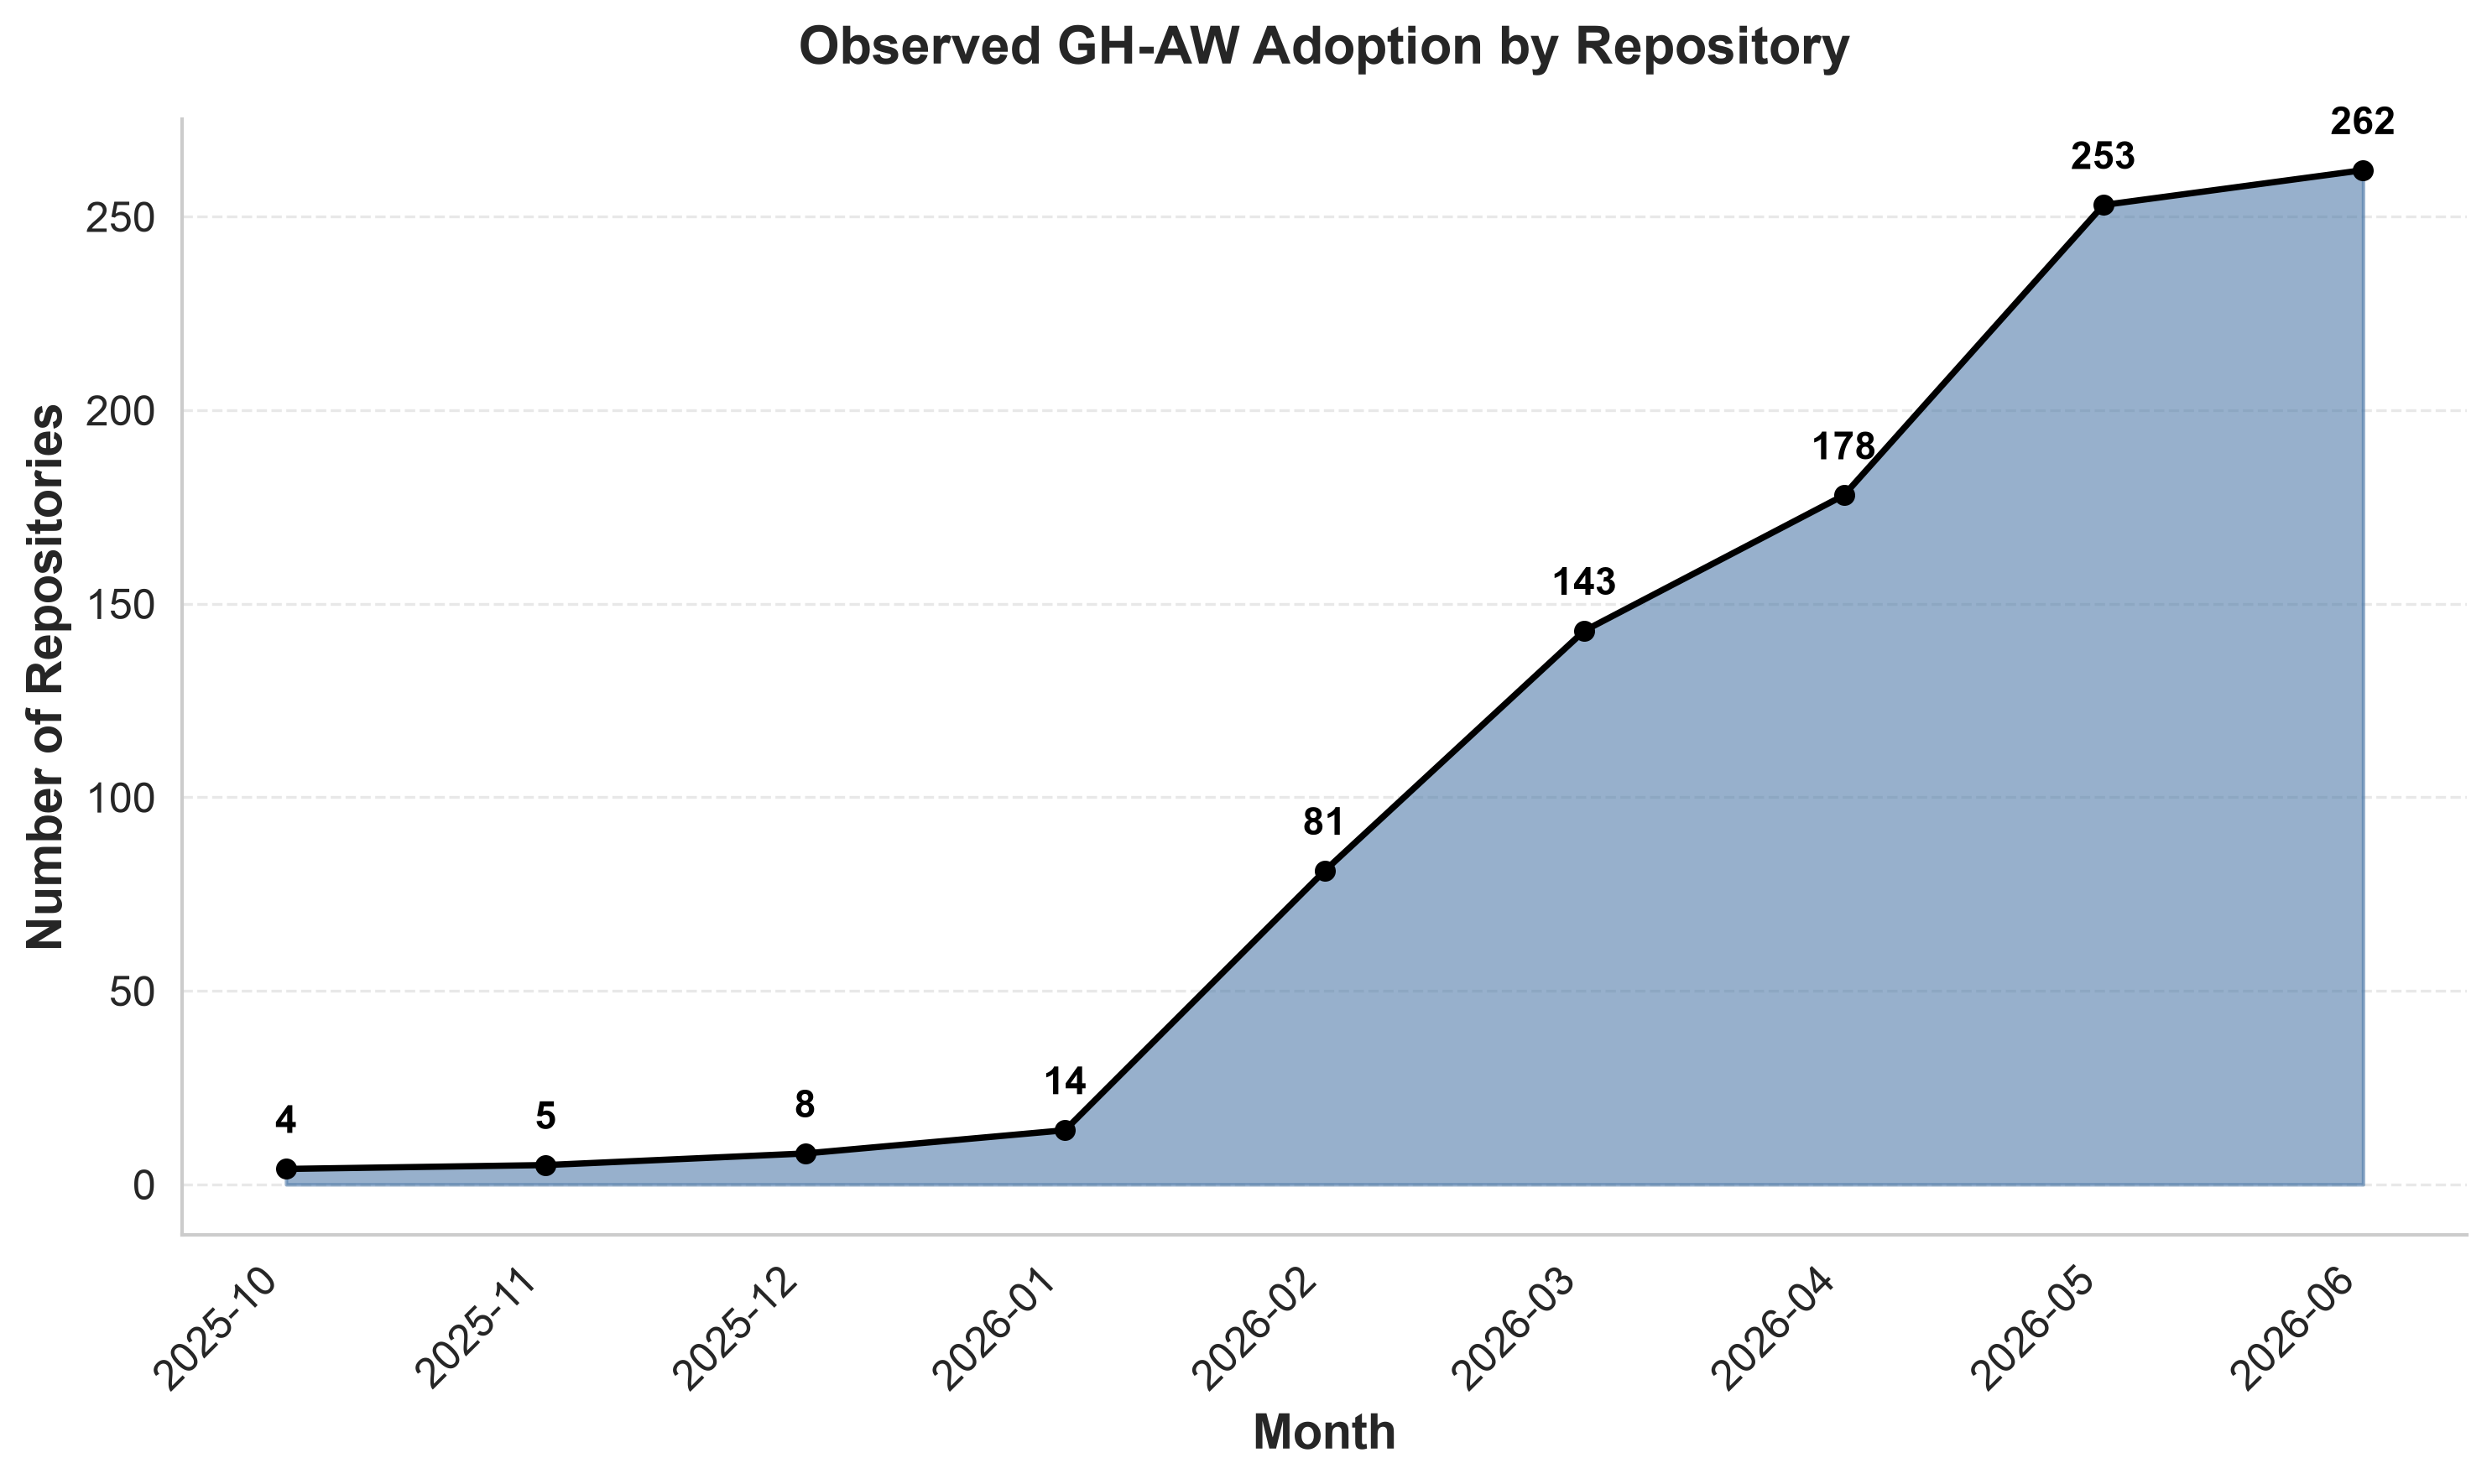

In [4]:
# ---- Figure 1: all repositories ----
monthly_all = monthly_cumulative(adoption_df)
plot_cumulative(
    monthly_all,
    title="Observed GH-AW Adoption by Repository",
    fname_stub="gawd_cumulative_all_repositories",
)
